# Memecoin season: hop on the hot dog-coin and outrun Bitcoin? 🐕
### A weekly momentum rotation across BTC / DOGE / SHIB — the strategy every bull market reinvents

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin_flip%3F: Busted](https://img.shields.io/badge/Beats_a_coin_flip%3F-Busted-8b949e?style=flat-square)

Every crypto cycle, the same story goes around: *forget boring Bitcoin — in a "memecoin season" the dog-coins go up 10×, 100×, 1000×, and all you have to do is rotate into whichever one is running.* It sounds almost too easy. So we built the literal strategy — every week, jump onto whichever of Bitcoin, Dogecoin and Shiba Inu has run hardest lately — and raced it against just buying and holding Bitcoin.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the vol math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **The one thing to know up front.** DOGE and SHIB are the *two memecoins that survived* out of literally thousands. In 2021 you didn't know which two those would be — so every number here is already the *best case*, and it still doesn't work. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"
BLUE = "#2b6cb0"

from memecoin_season import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    WK = data.weekly_prices()
    DAILY = data.load_prices()
else:
    WK = DAILY = None
print("real cache present:", HAVE_REAL,
      "| weekly bars:", (0 if WK is None else len(WK)))

# frozen headline numbers (mirror of docs/results.md)
R = {'win_lo': '2021-04-16', 'win_hi': '2026-06-26', 'n_weeks': 272, 'n_rot': 267, 'daily_lo': '2021-04-16', 'daily_hi': '2026-06-30', 'daily_n': 1902, 'fp': 'b75635d0b392', 'bh_btc': -5, 'bh_doge': -80, 'bh_shib': 300, 'rot_gross_total': -60, 'rot_gross_sharpe': 0.39, 'rot_gross_dd': -87, 'rot_total': -73.6, 'rot_cagr': -23.0, 'rot_sharpe': 0.34, 'rot_dd': -89, 'rot_vol': 162, 'rot_hit': 42.3, 'n_switches': 68, 'avg_turnover': 0.51, 'btc_total': -2.5, 'btc_cagr': -0.5, 'btc_sharpe': 0.26, 'btc_dd': -74, 'btc_vol': 55, 'ew_total': 217.2, 'ew_cagr': 25.0, 'ew_sharpe': 0.62, 'ew_dd': -80, 'ew_vol': 118, 'excess_mean_wk': 0.717, 'excess_t': 0.59, 'placebo_seeds': 4000, 'placebo_p_total': 0.517, 'placebo_p_sharpe': 0.41, 'rand_median_total': -72, 'rand_median_sharpe': 0.28, 'cost_sweep': {0: (-60, 0.39), 10: (-65, 0.37), 30: (-74, 0.34), 50: (-80, 0.31), 100: (-90, 0.23)}, 'mania_weeks': 33, 'mania_rot_total': 5.1, 'mania_rot_sharpe': 1.01, 'mania_btc_total': -7.2, 'mania_btc_sharpe': 0.18, 'mania_t': 0.83, 'after_weeks': 234, 'after_rot_total': -74.8, 'after_rot_sharpe': 0.08, 'after_btc_total': 29.6, 'after_btc_sharpe': 0.37, 'after_t': -0.32, 'syn_null_mean': 0.06, 'syn_null_sd': 1.15, 'syn_null_fire': 2, 'syn_planted_t': 5.12}


real cache present: True | weekly bars: 272


## The answer first

| Question | Answer |
|---|---|
| Did memecoins really blow past Bitcoin? | **Only one of them.** From April 2021 (when all three first trade) to mid-2026: SHIB **+300%**, but DOGE **-80%** and BTC **-5%**. "Memecoins win" is really "*the one memecoin that happened to survive* won." |
| Does the momentum rotation harvest it? | **No — it's a disaster.** Net of a gentle 30 bps a trade it returns **-74%** versus BTC's **-2%** and an equal-weight basket's **+217%** — an **89% drawdown** along the way. |
| Is it the trading costs killing it? | **No — it's broken even for free.** At **zero** cost the rotation still returns **-60%**. Chasing last week's winner in assets this violent just buys high and sells low. |
| Better than picking a coin at random? | **No.** A monkey throwing darts each week beats the momentum rotation **about half the time** (p = 0.52). The "signal" adds nothing. |

> The memecoin-season *phenomenon* is half-real (survivors did outrun BTC). The memecoin-season *strategy* is a mirage — it's the worst of every world.

## 1 · The claim

> *"In a bull market, Bitcoin is the slow money. The real gains are in memecoins — DOGE, SHIB and their cousins run 10-100× while BTC merely doubles. You don't even need to pick the winner ahead of time: just rotate into whatever's pumping and ride the momentum. Trend-following on steroids."*

It's a real observation dressed as a strategy. Memecoins *are* higher-beta than Bitcoin, and in euphoric windows they genuinely scream past it. The leap of faith is that a *mechanical momentum rotation* can convert that raw volatility into money you actually keep.

## 2 · So what?

If it worked, it would be the easiest trade in finance: no fundamentals, no valuation, just "buy what's going up" in the highest-octane corner of crypto. Every cycle, thousands of retail traders bet real money on exactly this thesis. The stakes are whether "memecoin season" is a *tradable edge* or just a survivorship-flavoured story people tell after the fact about the handful of coins that didn't go to zero.

## 3 · How would we even know?

- **The universe.** Bitcoin plus the two memecoins big enough to still be around: DOGE and SHIB. (That choice is already generous — see the survivorship warning.)
- **The rotation.** Every Friday, hold whichever of the three had the best trailing 4-week return; hold it the *next* week (no peeking); pay a realistic 30 bps each time you switch.
- **The race.** Compare total return, risk-adjusted return (Sharpe) and worst drawdown against just holding Bitcoin, and against a naive equal-weight basket.
- **The luck check.** Would picking a coin *at random* every week have done just as well? If yes, the momentum "signal" is worthless.

## 4 · The teardown — let's actually look

**First, the steelman: did the memecoins really outrun BTC?** Here are all three, rebased to 100 at the start of the common window.

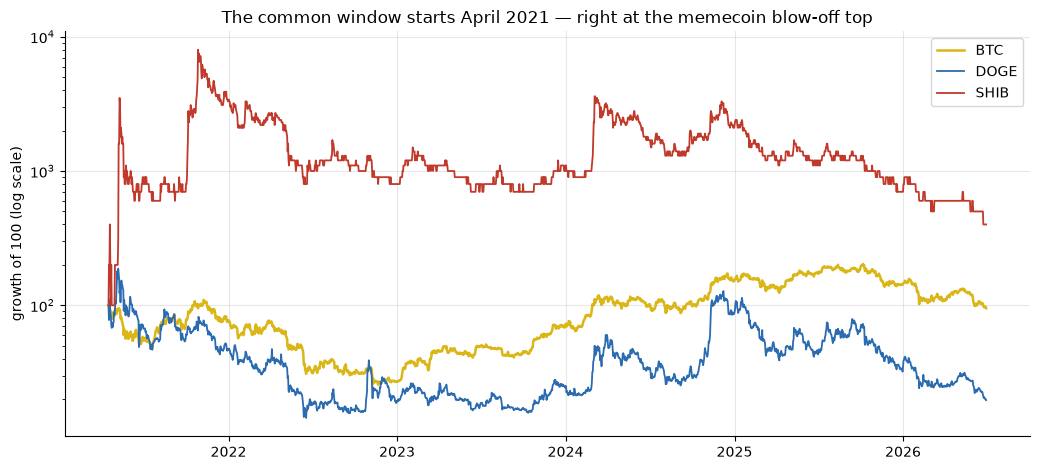

buy & hold over the window: BTC -5%, DOGE -80%, SHIB +300%


In [2]:
if HAVE_REAL:
    reb = DAILY / DAILY.iloc[0] * 100
else:
    reb = None
fig, ax = plt.subplots(figsize=(10.5, 4.8))
if HAVE_REAL:
    ax.plot(reb.index, reb['BTC'], color=AMBER, lw=1.8, label='BTC')
    ax.plot(reb.index, reb['DOGE'], color=BLUE, lw=1.3, label='DOGE')
    ax.plot(reb.index, reb['SHIB'], color=RED, lw=1.3, label='SHIB')
    ax.set_yscale('log')
    ax.set_ylabel('growth of 100 (log scale)')
else:
    ax.bar(['BTC','DOGE','SHIB'], [R['bh_btc'], R['bh_doge'], R['bh_shib']],
           color=[AMBER, BLUE, RED])
    ax.set_ylabel('total return, %')
ax.set_title('The common window starts April 2021 — right at the memecoin blow-off top')
ax.legend(); plt.tight_layout(); plt.show()
print(f"buy & hold over the window: BTC {R['bh_btc']:+d}%, DOGE {R['bh_doge']:+d}%, SHIB {R['bh_shib']:+d}%")

Look closely: only **SHIB** (+300%) actually beat holding cash. **DOGE** lost **80%** — because the window starts in April 2021, right at DOGE's mania peak, and it never came back. "Memecoins beat Bitcoin" turns out to mean "*the one that kept going up* beat Bitcoin" — which you only know in hindsight. Now: can a momentum rotation navigate this?

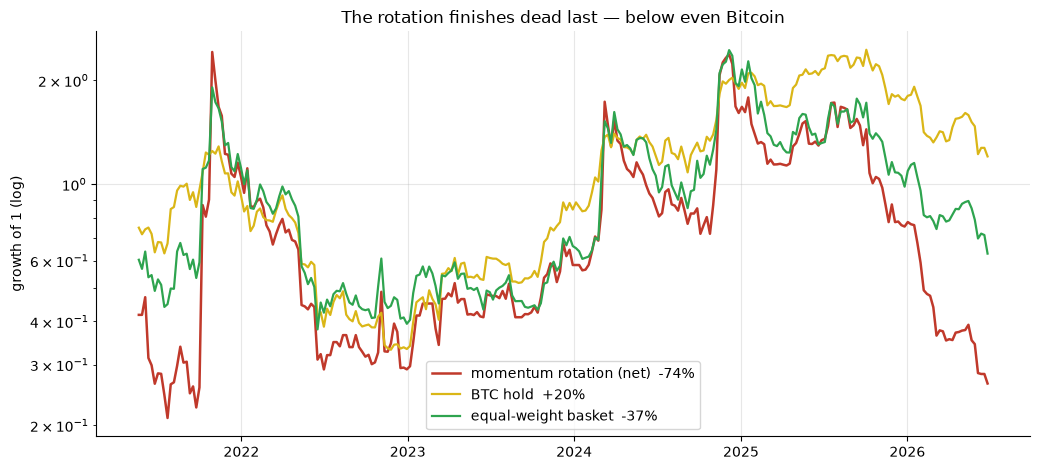

rotation net -74%  |  BTC -2%  |  equal-weight +217%


In [3]:
if HAVE_REAL:
    net = st.run_rotation(WK, lookback=4, cost_bps=30.0)
    btc = st.btc_hodl(WK); ew = st.equal_weight(WK)
    w_rot = (1+net['net_ret']).cumprod(); w_btc = (1+btc.reindex(net['net_ret'].index)).cumprod()
    w_ew  = (1+ew.reindex(net['net_ret'].index)).cumprod()
    fig, ax = plt.subplots(figsize=(10.5, 4.8))
    ax.plot(w_rot.index, w_rot, color=RED, lw=1.8, label=f"momentum rotation (net)  {(w_rot.iloc[-1]-1)*100:+.0f}%")
    ax.plot(w_btc.index, w_btc, color=AMBER, lw=1.6, label=f"BTC hold  {(w_btc.iloc[-1]-1)*100:+.0f}%")
    ax.plot(w_ew.index, w_ew, color=GREEN, lw=1.6, label=f"equal-weight basket  {(w_ew.iloc[-1]-1)*100:+.0f}%")
    ax.set_yscale('log'); ax.set_ylabel('growth of 1 (log)')
else:
    fig, ax = plt.subplots(figsize=(9.2, 4.6))
    ax.bar(['rotation\n(net)','BTC hold','equal-weight'], [R['rot_total'], R['btc_total'], R['ew_total']],
           color=[RED, AMBER, GREEN])
    ax.set_ylabel('total return, %')
ax.set_title('The rotation finishes dead last — below even Bitcoin')
ax.legend(); plt.tight_layout(); plt.show()
print(f"rotation net {R['rot_total']:+.0f}%  |  BTC {R['btc_total']:+.0f}%  |  equal-weight +{R['ew_total']:.0f}%")

The momentum rotation ends at **-74%** — worse than simply holding Bitcoin (**-2%**), and a universe away from just equal-weighting the three coins (**+217%**). The strategy that was supposed to *harvest* the mania managed to lose money in one of the great speculative runs of all time. Why? **Because it chases.**

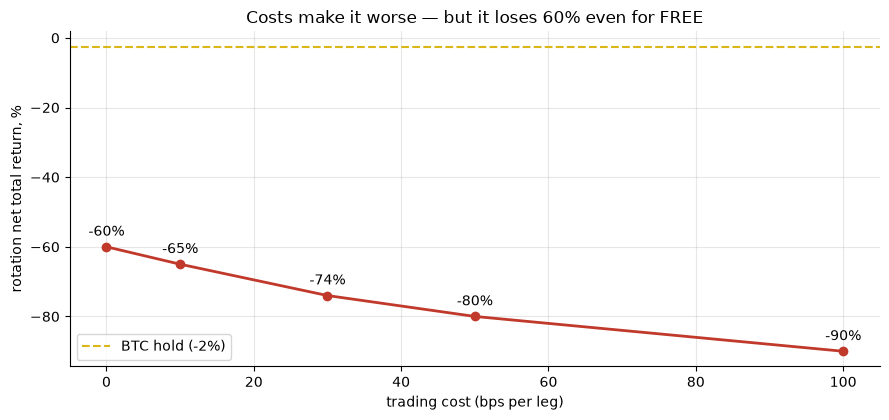

In [4]:
sweep = R['cost_sweep']
cs = sorted(sweep); tot = [sweep[c][0] for c in cs]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(cs, tot, 'o-', color=RED, lw=2)
ax.axhline(R['btc_total'], ls='--', color=AMBER, label=f"BTC hold ({R['btc_total']:+.0f}%)")
for c, v in zip(cs, tot): ax.annotate(f'{v:+d}%', (c, v), textcoords='offset points', xytext=(0,8), ha='center')
ax.set_xlabel('trading cost (bps per leg)'); ax.set_ylabel('rotation net total return, %')
ax.set_title('Costs make it worse — but it loses 60% even for FREE')
ax.legend(); plt.tight_layout(); plt.show()

That's the tell: at **zero** trading cost the rotation still ends around **-60%**. This isn't a good strategy ruined by fees — it's a strategy that *structurally* buys whatever just spiked (near its local top) and sells whatever just dropped (near its local bottom), in assets that swing **±162% a year**. The volatility itself is the tax. **Last check: is the momentum signal even better than random?**

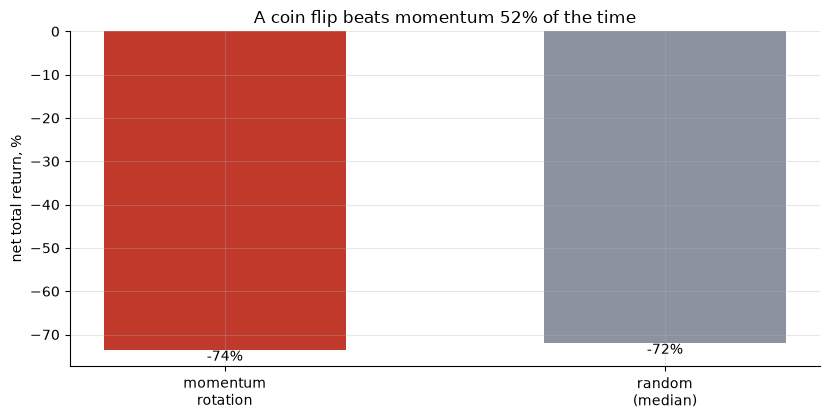

momentum -74%  vs random-rotation median -72% | p(random >= momentum) = 0.517


In [5]:
labels = ['momentum\nrotation', 'random\n(median)']
vals = [R['rot_total'], R['rand_median_total']]
fig, ax = plt.subplots(figsize=(8.4, 4.3))
ax.bar(labels, vals, color=[RED, GREY], width=.55)
for i, v in enumerate(vals): ax.annotate(f'{v:+.0f}%', (i, v), ha='center', va='top')
ax.set_ylabel('net total return, %')
ax.set_title(f"A coin flip beats momentum {R['placebo_p_total']*100:.0f}% of the time")
plt.tight_layout(); plt.show()
print(f"momentum {R['rot_total']:+.0f}%  vs random-rotation median {R['rand_median_total']:+d}% "
      f"| p(random >= momentum) = {R['placebo_p_total']:.3f}")

Picking a coin **at random** every week does about as well as the momentum rule — a random calendar matches or beats it **52% of the time**. The "momentum" adds nothing you couldn't get from a dartboard. The signal is noise.

## 5 · The verdict

- **Signal — None.** The rotation's edge over Bitcoin is statistically zero (*t* = 0.59), a random coin-flip does as well (*p* = 0.52), and even the raw "memecoins won" claim is just one survivor (SHIB) carrying two losers.
- **Tradability — Mirage.** Net of a mild 30 bps it returns **-74%** vs BTC **-2%** and an equal-weight basket **+217%**, with an **89%** drawdown — and it loses money even at zero cost.
- **"Beats a coin flip?" — Busted.** No.

## 6 · Going further 🚪

- **The survivorship point is the whole point.** The only thing that "worked" here was owning SHIB from the start — and in April 2021 SHIB was one of ten thousand indistinguishable dog-coins, most now worthless. A backtest on the survivors flatters *any* buy-and-hold and still can't rescue the rotation.
- **What might change the picture:** a proper *cash* exit (sit out when all momentum is negative) softens the drawdown, but on this tape it still trails buy-and-hold — try it in the quants notebook. A slower lookback? A bigger, point-in-time memecoin universe including the dead ones? (That last one would make the numbers *worse*, not better.)

*Think a different lookback, a cash filter, or a wider universe cracks it? Fork the repo and try — the engine is ~250 lines and the whole thing reruns offline.*